# XGBoost Time Series Training (`net_injection`)

This notebook trains an XGBoost Regressor with strict chronological splitting and `TimeSeriesSplit` cross-validation.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)


In [2]:
DATA_PATH = "../data/processed/dataset_v2_featured.csv"
df = pd.read_csv(DATA_PATH)

date_col = "Date" if "Date" in df.columns else "date"
df = df.rename(columns={date_col: "date"})
df["date"] = pd.to_datetime(df["date"], errors="coerce")

feature_cols = [
    "hdd",
    "wind_weighted",
    "day_sin",
    "day_cos",
    "day_of_week",
    "is_weekend",
    "stock_twh_lag_1",
    "stock_fill_rate",
    "hdd_wind",
    "cold_weekend",
    "net_injection_lag_1",
    "net_injection_lag_7",
    "hdd_roll_mean_7",
    "wind_roll_mean_7",
]
target_col = "net_injection"

required_cols = ["date", "country", target_col, *feature_cols]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = (
    df[required_cols]
    .dropna(subset=required_cols)
    .sort_values("date")
    .reset_index(drop=True)
)

print(df[["date", "country", target_col]].head())
print(df[["date", "country", target_col]].tail())
print(f"Rows after cleaning: {len(df):,}")


        date country  net_injection
0 2016-01-09      BE        -0.0011
1 2016-01-09      NL        -0.6595
2 2016-01-09      DE        -0.4414
3 2016-01-09      FR        -0.5906
4 2016-01-09      IT        -0.9008
            date country  net_injection
18355 2026-02-09      DE        -1.6490
18356 2026-02-09      BE        -0.0654
18357 2026-02-09      FR        -0.6797
18358 2026-02-09      IT        -0.9452
18359 2026-02-09      NL        -1.1197
Rows after cleaning: 18,360


In [3]:
cutoff_date = pd.Timestamp("2023-01-01")

train_df = df[df["date"] < cutoff_date].copy()
test_df = df[df["date"] >= cutoff_date].copy()

if train_df.empty:
    raise ValueError("Train set is empty. Check cutoff_date and input data.")
if test_df.empty:
    raise ValueError("Test set is empty. Check cutoff_date and input data.")

X_train_raw = train_df[feature_cols + ["country"]]
y_train = train_df[target_col]

X_test_raw = test_df[feature_cols + ["country"]]
y_test = test_df[target_col]

X_train = pd.get_dummies(X_train_raw, columns=["country"], drop_first=False)
X_test = pd.get_dummies(X_test_raw, columns=["country"], drop_first=False)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(
    f"Train rows: {len(train_df):,} | period: {train_df['date'].min().date()} -> {train_df['date'].max().date()}"
)
print(
    f"Test rows (>=2023): {len(test_df):,} | period: {test_df['date'].min().date()} -> {test_df['date'].max().date()}"
)
print(f"Encoded feature count: {X_train.shape[1]}")


Train rows: 12,680 | period: 2016-01-09 -> 2022-12-31
Test rows (>=2023): 5,680 | period: 2023-01-01 -> 2026-02-09
Encoded feature count: 19


In [4]:
search_space = {
    "n_estimators": [300, 500, 700, 1000],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.5],
    "reg_alpha": [0, 0.01, 0.1],
    "reg_lambda": [1, 5, 10],
}

base_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=1,
    tree_method="hist",
)

tscv = TimeSeriesSplit(n_splits=5)

from math import prod
print({k: len(v) for k, v in search_space.items()})
print("candidates (full grid):", prod(len(v) for v in search_space.values()))
N_ITER = 2000
print("sampled candidates:", N_ITER)
print("total fits (5 folds):", 5 * N_ITER)

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=search_space,
    n_iter=N_ITER,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=True,
)

random_search.fit(X_train, y_train)

print("Best hyperparameters:", random_search.best_params_)
print(f"Best CV MAE: {-random_search.best_score_:.6f}")


{'n_estimators': 4, 'max_depth': 4, 'learning_rate': 4, 'subsample': 4, 'colsample_bytree': 4, 'min_child_weight': 3, 'gamma': 3, 'reg_alpha': 3, 'reg_lambda': 3}
candidates (full grid): 82944
sampled candidates: 2000
total fits (5 folds): 10000
Fitting 5 folds for each of 2000 candidates, totalling 10000 fits
Best hyperparameters: {'subsample': 0.7, 'reg_lambda': 10, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 1.0}
Best CV MAE: 0.147125


In [5]:
best_params = random_search.best_params_

best_model = XGBRegressor(
    objective="reg:squarederror",
    n_jobs=-1,
    tree_method="hist",
    **best_params,
)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

results = test_df[["date", "country", target_col]].copy()
results["prediction"] = y_pred
results = results.sort_values("date").reset_index(drop=True)
results.head()


,date,country,net_injection,prediction
0,2023-01-01,DE,1.0148,0.783626
1,2023-01-01,BE,0.0305,0.043132
2,2023-01-01,NL,0.1200,0.189473
3,2023-01-01,IT,0.0318,0.008563
4,2023-01-01,FR,0.0640,0.192083


In [6]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Evaluation on test set (>= 2023-01-01)")
print(f"MAE : {mae:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"R2  : {r2:.6f}")


Evaluation on test set (>= 2023-01-01)
MAE : 0.108779
RMSE: 0.269763
R2  : 0.826131


In [7]:
# Comparatif XGBoost vs baselines simples
def _metrics(y_true, y_hat):
    return {
        "MAE": mean_absolute_error(y_true, y_hat),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_hat)),
        "R2": r2_score(y_true, y_hat),
    }

y_pred_mean = np.full(len(y_test), y_train.mean())
y_pred_median = np.full(len(y_test), y_train.median())
y_pred_lag1 = test_df["net_injection_lag_1"].to_numpy()

comparison_rows = [
    {"Model": "XGBoost (best)", **_metrics(y_test, y_pred)},
    {"Model": "Baseline Mean(train)", **_metrics(y_test, y_pred_mean)},
    {"Model": "Baseline Median(train)", **_metrics(y_test, y_pred_median)},
    {"Model": "Baseline Lag-1", **_metrics(y_test, y_pred_lag1)},
]

comparison_df = (
    pd.DataFrame(comparison_rows)
    .sort_values("MAE")
    .reset_index(drop=True)
)
comparison_df


,Model,MAE,RMSE,R2
0,XGBoost (best),0.108779,0.269763,0.826131
1,Baseline Lag-1,0.135556,0.329716,0.740261
2,Baseline Median(train),0.456286,0.654597,-0.023780
3,Baseline Mean(train),0.457020,0.651253,-0.013348


Zoom January 2023 points: 31


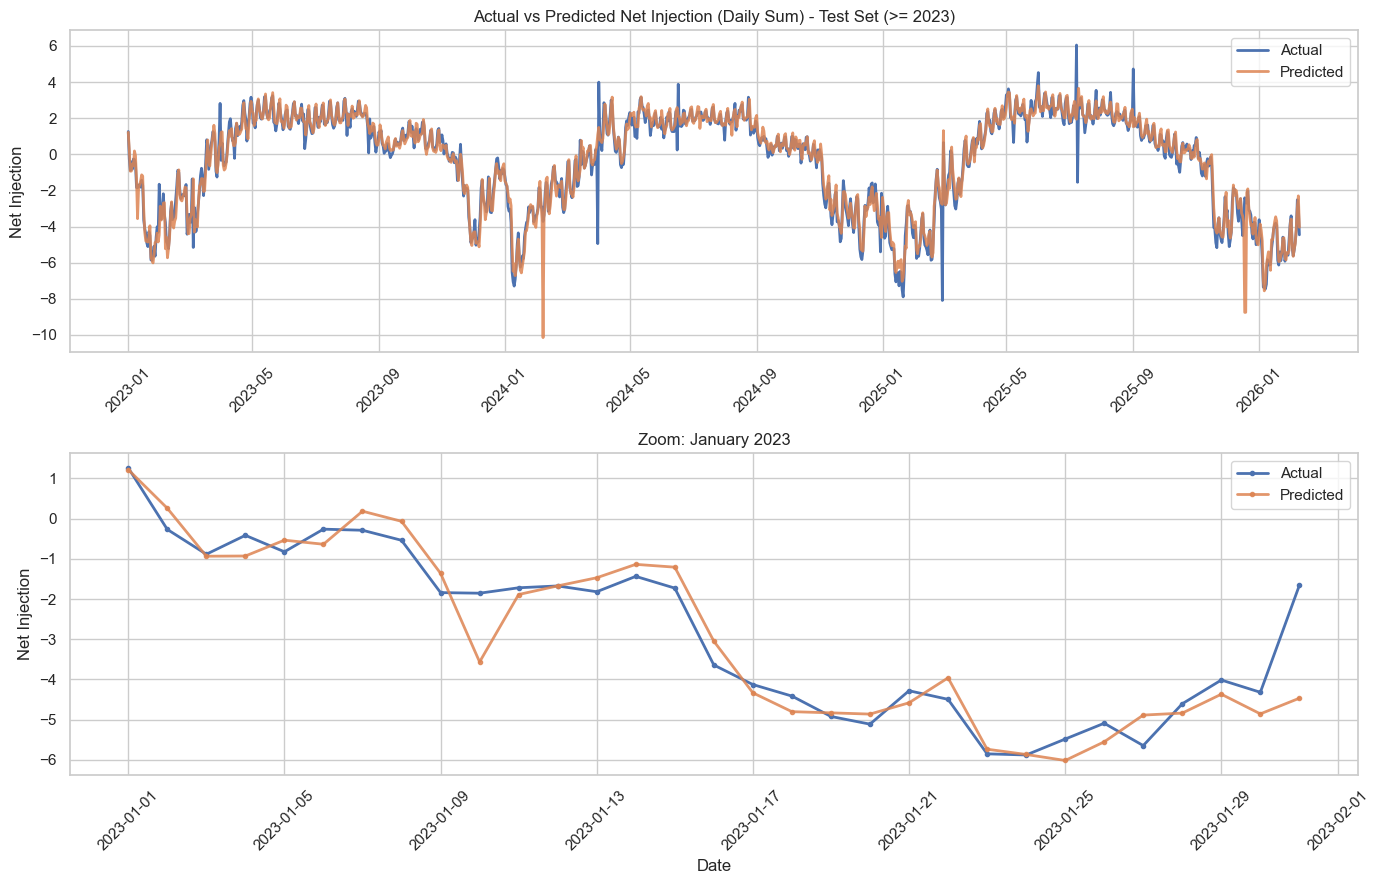

In [8]:
daily_results = (
    results.groupby("date", as_index=False)[[target_col, "prediction"]]
    .sum()
    .sort_values("date")
)

zoom_start = pd.Timestamp("2023-01-01")
zoom_end = pd.Timestamp("2023-02-01")
zoom_df = daily_results[
    (daily_results["date"] >= zoom_start)
    & (daily_results["date"] < zoom_end)
]

if zoom_df.empty:
    first_test_year = int(daily_results["date"].min().year)
    zoom_start = pd.Timestamp(f"{first_test_year}-01-01")
    zoom_end = pd.Timestamp(f"{first_test_year}-02-01")
    zoom_df = daily_results[
        (daily_results["date"] >= zoom_start)
        & (daily_results["date"] < zoom_end)
    ]
    print(
        f"Jan 2023 absent du test courant. Zoom appliqué sur janvier {first_test_year}."
    )
else:
    print(f"Zoom January 2023 points: {len(zoom_df)}")

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)

axes[0].plot(daily_results["date"], daily_results[target_col], label="Actual", linewidth=2)
axes[0].plot(daily_results["date"], daily_results["prediction"], label="Predicted", linewidth=2, alpha=0.85)
axes[0].set_title("Actual vs Predicted Net Injection (Daily Sum) - Test Set (>= 2023)")
axes[0].set_ylabel("Net Injection")
axes[0].legend()

axes[1].plot(zoom_df["date"], zoom_df[target_col], label="Actual", linewidth=2, marker="o", markersize=3)
axes[1].plot(zoom_df["date"], zoom_df["prediction"], label="Predicted", linewidth=2, alpha=0.85, marker="o", markersize=3)
axes[1].set_title(f"Zoom: {zoom_start.strftime('%B %Y')}")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Net Injection")
axes[1].legend()

for ax in axes:
    for label in ax.get_xticklabels():
        label.set_rotation(45)

plt.tight_layout()
plt.show()


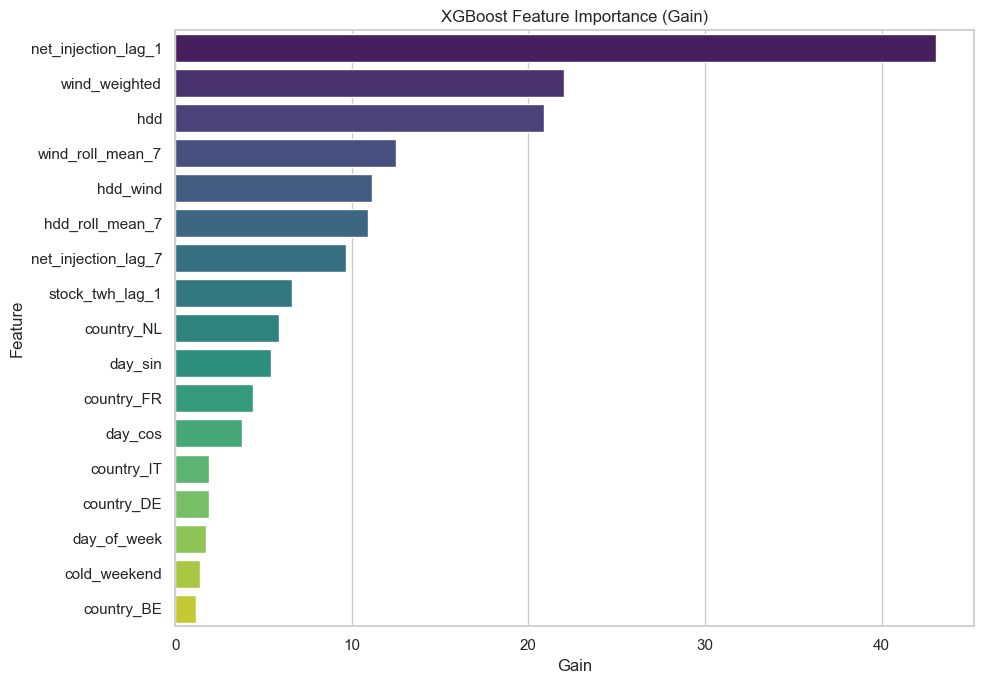

,feature,importance_gain
8,net_injection_lag_1,43.084347
1,wind_weighted,22.021446
0,hdd,20.888393
11,wind_roll_mean_7,12.474925
6,hdd_wind,11.149787
10,hdd_roll_mean_7,10.930660
9,net_injection_lag_7,9.641798
5,stock_twh_lag_1,6.633272
16,country_NL,5.873695
2,day_sin,5.430577


In [9]:
gain_scores = best_model.get_booster().get_score(importance_type="gain")
importance_df = (
    pd.DataFrame(
        {
            "feature": list(gain_scores.keys()),
            "importance_gain": list(gain_scores.values()),
        }
    )
    .sort_values("importance_gain", ascending=False)
)

if importance_df.empty:
    print("No feature importance scores were returned by the model.")
else:
    top_n = min(20, len(importance_df))
    plt.figure(figsize=(10, 7))
    sns.barplot(
        data=importance_df.head(top_n),
        x="importance_gain",
        y="feature",
        palette="viridis",
    )
    plt.title("XGBoost Feature Importance (Gain)")
    plt.xlabel("Gain")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

importance_df.head(10)
